In [ ]:
import json

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import LineString

from bluebikes_rebalancing.config import LOCAL_DATA_DIR
from bluebikes_rebalancing.plots import COLORS, plot_points_on_map

In [2]:
# Data directory for station files
stations_dir = LOCAL_DATA_DIR / "raw" / "stations"

# Load stations of interest (list of short names)
soi_json_filename = "stations_of_interest.json"
soi = json.load(open(stations_dir / soi_json_filename))

# Load full station metadata
stations_csv_filename = "station_information.csv"
df_stations = pd.read_csv(stations_dir / stations_csv_filename)

# Filter to stations of interest and sort
filt = df_stations["short_name"].isin(soi)
df_soi = df_stations.loc[filt, :].sort_values(by="short_name").reset_index(drop=True)

# Keep only relevant columns
cols = ["short_name", "lat", "lon", "capacity"]
df_soi = df_soi[cols]

Lets define the bbox for our network analysis

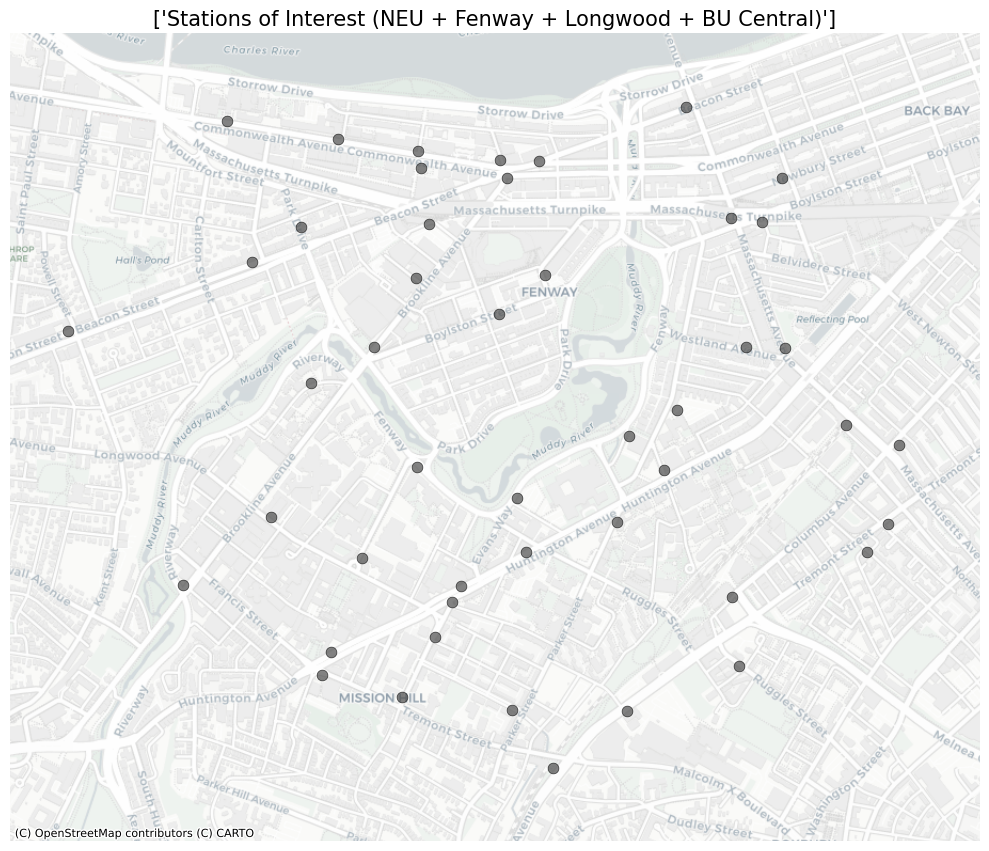

(<Figure size 1000x1000 with 1 Axes>,
 <Axes: title={'center': "['Stations of Interest (NEU + Fenway + Longwood + BU Central)']"}>)

In [3]:
BBOX = (-71.117, 42.329, -71.078, 42.353)  # WSEN

plot_points_on_map(
    df_soi,
    group_col="short_name",
    color_list=[COLORS[-1]],
    legend_labels=["Stations of Interest"],
    title=["Stations of Interest (NEU + Fenway + Longwood + BU Central)"],
    show_labels=True,
    markersize_list=[60],
    bbox=BBOX,
    zoom=15,
    figsize=(10, 10),
)

Download the network for the area where our stations of interest lies

In [4]:
import osmnx as ox

In [5]:
network = ox.graph_from_bbox(BBOX, network_type='drive', simplify=True, truncate_by_edge=True)

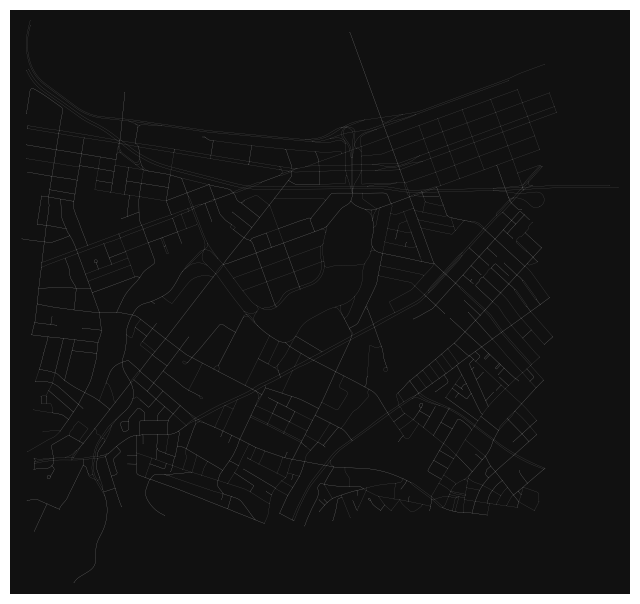

In [6]:
fig, ax = ox.plot_graph(network, node_size=.05, node_color='w', edge_color='gray', edge_linewidth=0.1)

In [7]:
# Get edge speed
network = ox.add_edge_speeds(network)
gdf_nodes, gdf_edges = ox.graph_to_gdfs(network)

In [8]:
gdf_edges["speed_kph"].value_counts().sort_index()

speed_kph
16.093400       8
24.140100       4
32.186800     298
38.347417       5
40.233500    1571
41.448674      12
44.256850       5
44.458017      16
46.388426      14
46.390708       8
48.280200     185
52.303550       2
56.326900       2
56.326900       1
64.373600      11
80.467000       4
88.513700       2
Name: count, dtype: int64

In [9]:
def plot_edges_by_range(gdf, col, val_range):
    filt = (gdf[col] >= val_range[0]) & (gdf[col] < val_range[1])

    fig, ax = plt.subplots(1, 1)
    fig.patch.set_facecolor('black')
    ax.set_facecolor('black')

    gdf.loc[~filt, :].plot(ax=ax, color="gray", linewidth=.1)
    gdf.loc[filt, :].plot(ax=ax, color="white", linewidth=.3)

    plt.xticks([])
    plt.yticks([])
    plt.xlabel('')
    plt.ylabel('')

    plt.show()

Common streets to ~15 km/h -> x * .5

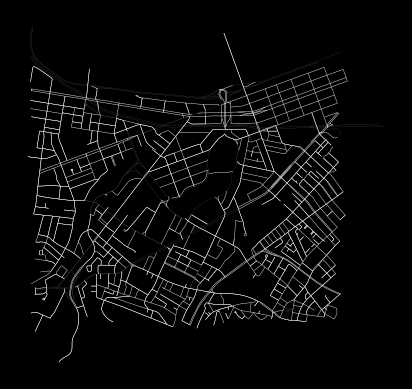

In [10]:
plot_edges_by_range(gdf_edges, "speed_kph", (0, 42))

Mid avenues to ~25 km/h -> x * .6

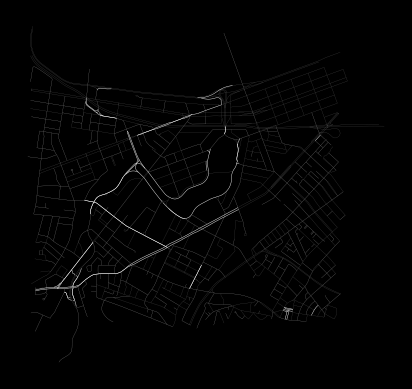

In [11]:
plot_edges_by_range(gdf_edges, "speed_kph", (42, 50))

fast roads to ~50 km/h -> x * .8

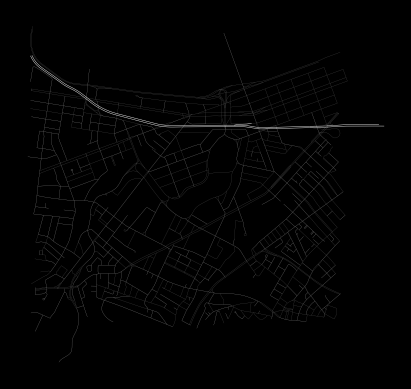

In [12]:
plot_edges_by_range(gdf_edges, "speed_kph", (70, 100))

In [13]:
# Edit edge speeds based on relevation from Google Maps
def change_speed(x):
    if x >= 50:
        return x*.8
    elif (x < 50) and (x > 42):
        return x*.6
    elif (x <= 50) and (x >= 35):
        return x*.5
    else:
        return x
    
gdf_edges["speed_kph"] = gdf_edges["speed_kph"].apply(change_speed)

network = ox.graph_from_gdfs(gdf_nodes, gdf_edges)

network = ox.add_edge_travel_times(network)

#### Calculate distance between each pair of points (time and distance)

In [14]:
DEPOT_LL = (42.338629, -71.106500)
df_depot_start = pd.DataFrame(
    [{"short_name": "depot_start", "lat": DEPOT_LL[0], "lon": DEPOT_LL[1]}]
)
df_depot_end = pd.DataFrame([{"short_name": "depot_end", "lat": DEPOT_LL[0], "lon": DEPOT_LL[1]}])

df_soi_depot = pd.concat(
    [df_depot_start, df_soi.drop(columns="capacity"), df_depot_end]
).reset_index(drop=True)

In [15]:
df_od = (
    df_soi_depot[["short_name", "lon", "lat"]]
    .rename(columns={"short_name": "short_name_o", "lon": "lon_o", "lat": "lat_o"})
    .merge(
        df_soi_depot[["short_name", "lon", "lat"]].rename(
            columns={"short_name": "short_name_d", "lon": "lon_d", "lat": "lat_d"}
        ),
        how="cross",
    )
).reset_index(drop=True)

In [16]:
origs = ox.distance.nearest_nodes(network, X=df_od["lon_o"], Y=df_od["lat_o"])
dests = ox.distance.nearest_nodes(network, X=df_od["lon_d"], Y=df_od["lat_d"])

routes = ox.shortest_path(network, origs, dests, weight="travel_time")

In [17]:
df_od["route"] = routes

In [18]:
assert df_od["route"].isna().sum() == 0

In [19]:
dict_hexid_point = {idx : gdf_nodes.loc[idx, "geometry"] for idx in gdf_nodes.index}

def route_2_geom(id_list):
    return LineString([dict_hexid_point[i] for i in id_list]) if len(id_list)!=1 else dict_hexid_point[id_list[0]]

df_od['geometry'] = df_od['route'].apply(lambda x: route_2_geom(x))

gdf_od = gpd.GeoDataFrame(df_od, geometry="geometry", crs="EPSG:4326")

Check the internal ox calculation for travel time is ok

In [20]:
edge = network[61343472][12745218452][0]
length_km = edge["length"] / 1000
speed_kph = edge["speed_kph"]
travel_time_calc = length_km / speed_kph * 3600

print(f"Length: {length_km:.4f} km")
print(f"Speed: {speed_kph:.4f} kph")
print(f"Travel time (calculated): {travel_time_calc:.4f} s")
print(f"Travel time (stored):     {edge['travel_time']:.4f} s")

Length: 0.1152 km
Speed: 28.9681 kph
Travel time (calculated): 14.3210 s
Travel time (stored):     14.3210 s


Calculate each route distance and travel time using the features in the network

In [21]:
def route_travel_time(route, graph):
    if len(route) == 1:
        return 0.0, 0.0
    travel_time = sum(graph[u][v][0]["travel_time"] for u, v in zip(route[:-1], route[1:]))
    length_m = sum(graph[u][v][0]["length"] for u, v in zip(route[:-1], route[1:]))
    return travel_time, length_m


df_od[["ttime_s", "dist_m"]] = df_od["route"].apply(
    lambda r: pd.Series(route_travel_time(r, network))
)

Validate distance calculation using the geometry of the route projected into nad83

In [22]:
gdf_od_nad83 = gdf_od.to_crs("EPSG:26986")
df_od["distance_m_check"] = gdf_od_nad83.geometry.length

df_od["length_diff_m"] = df_od["dist_m"] - df_od["distance_m_check"]
df_od[["dist_m", "distance_m_check", "length_diff_m"]].describe()

,dist_m,distance_m_check,length_diff_m
count,2401.000000,2401.000000,2401.000000
mean,1602.744143,1592.764457,9.979686
std,761.347615,756.577166,12.519195
min,0.000000,0.000000,-2.700787
25%,1035.374555,1029.183230,0.882093
50%,1589.802600,1576.877780,6.001315
75%,2189.615614,2174.049492,16.588695
max,3660.894940,3633.233409,134.959171


---

Graphical validation of the procedure

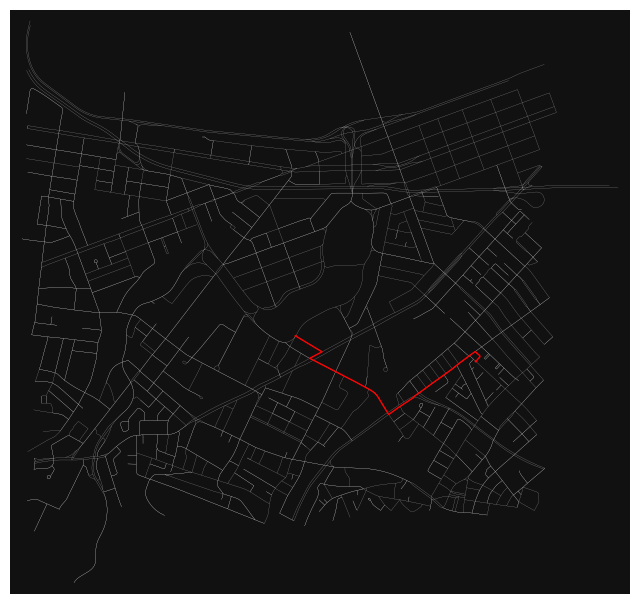

In [78]:
import random
n = random.randint(0, df_od.shape[0] - 1)

fig, ax = ox.plot_graph_route(
    network,
    df_od.loc[n, "route"],
    route_linewidth=1,
    route_alpha=1,
    orig_dest_size=3,
    **{"node_size":0, "node_color": "r", "edge_color": "w", "edge_linewidth": 0.1},
)